In [1]:
import numpy as np
import torch
import scanpy as sc
import anndata as ad
import os
import pandas as pd
from utils.preprocess import *
import scipy as sp

In [2]:
import os
os.environ["PYKEOPS_VERBOSE"] = "0"
import sys
sys.path.append(os.path.abspath("conditional-flow-matching"))
    
import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
import torch
import torchsde
from torchdyn.core import NeuralODE
from tqdm import tqdm

from torchcfm.conditional_flow_matching import *
from torchcfm.models import MLP
from visualize.plots import *

In [3]:
import random
import umap
from models.modules import *
from visualize.plots import *

In [4]:
import matplotlib.pyplot as plt
%matplotlib inline

In [5]:
from scripts.run_model import *
from eval.eval import *

In [6]:
%reload_ext autoreload
%autoreload 2

In [7]:
############################################################

In [8]:
path = "/home/azweig/projects/zebrafish/data/"
suffix = "simulation_gene_data.csv"
df = pd.read_csv(path+suffix)

In [9]:
X = df[['x1', 'x2']].to_numpy()
adata = ad.AnnData(X)
adata.obs['timepoint'] = df['samples'].astype(int).tolist()
adata.obs['gene_target'] = pd.Categorical(["ctrl-inj"] * adata.shape[0])
adata.obsm['X_pca'] = adata.X
adata.varm['PCs'] = np.zeros((2, 2))
adata.obsm['X_umap'] = adata.X
values = ["ctrl-inj"]

In [10]:
############################################################

stable
False    488
True     202
Name: count, dtype: int64

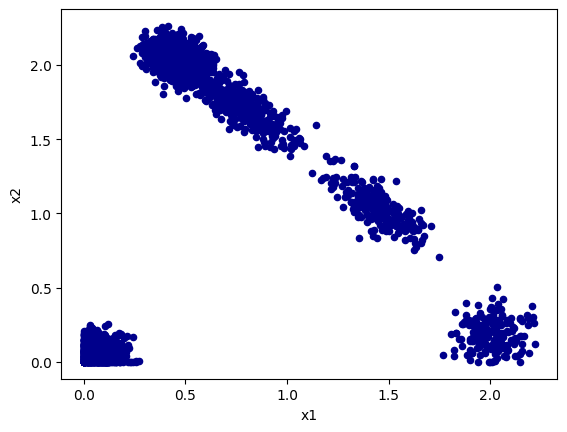

In [11]:
#Explore the two cell types

df.plot.scatter(x='x1', y='x2', c='DarkBlue')
df['stable'] = (df['x1'] <= 1) & (df['x2'] <= 1)
df[df['samples'] == 3.0]['stable'].value_counts()

In [12]:
############################################################

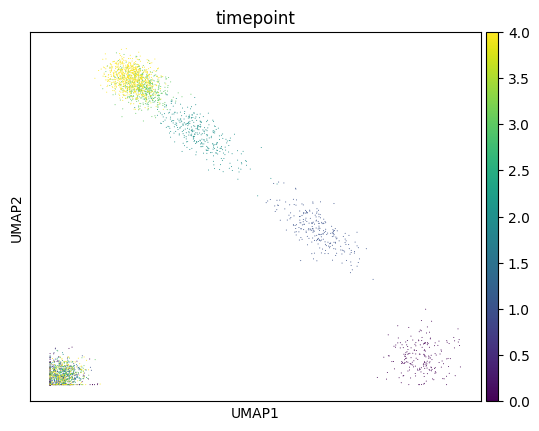

In [13]:
sc.pl.umap(
    adata,
    color="timepoint",
    size=2,
)

In [14]:
fm_config = Config(
    {        
        "model_class": "uflow",
        'max_epochs': 5000,
        "lr": 1e-3,
        "dropout": 0.0, #TODO: not used rn
        "pc_dim": 2,
        "cond_dim": 2,
        "hidden_dim": 512,
        # "batch_size": 256,
        "batch_size": 400,
        "num_freq": 64,
        "num_layers": 3,
        "activation": "selu",
        "constrain": True,
        "force_cpu": False,
        "gradient_clip_val": 0,
        "loader_batch_size": 10,
        "accumulate_grad_batches": 1,
        "warmup_steps": 500,

        "reg": 0.05,
        "reg_m": 1.7,

        # "reg": 0.0,
        # "reg_m": 100.0,

        "latent_dim": 256,
        "ema_decay": 0.9999,
        "sigma": 0.1,
        "cfg_p_u": 0.0, #TODO: do we want this?  I think it corresponds to having our ctrl trained over all samples
        "cfg_w": 1.0,
    }
)

In [15]:
wandb.finish()

In [16]:
config = fm_config

In [17]:
holdout_t = 2

In [18]:
adata_train = adata[adata.obs['timepoint'] != holdout_t]

In [19]:
conditions, dataset = extract_dataset(adata_train, values)

In [20]:
for obj in dataset:
    x0, x1, t0, t1, gene_target = obj
    print(x0.shape, x1.shape, t0, t1, gene_target, x0.dtype)

torch.Size([400, 2]) torch.Size([442, 2]) 0 1 ctrl-inj torch.float32
torch.Size([442, 2]) torch.Size([690, 2]) 1 3 ctrl-inj torch.float32
torch.Size([690, 2]) torch.Size([969, 2]) 3 4 ctrl-inj torch.float32


In [21]:
project = "embryoid_toy"
model = run_model(config = config,
                  project = project,
                  adata = adata_train,
                  values = values,
                  conditions = conditions,
                  dataset = dataset)

wandb: Currently logged in as: az831 (az831-new-york-genome-center) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/azweig/miniconda3/envs/spatialenv/lib/python3.10/site-packages/pytorch_lightning/loggers/wandb.py:397: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.
wandb: logging graph, to disable use `wandb.watch(log_graph=False)`
You are using a CUDA device ('NVIDIA GeForce RTX 4080 SUPER') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name       | Type | Params | Mode 
--------------------------------------------
0 | flow_net   | EMA 

epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇█████
train_loss,█▂▃▂▂▂▂▂▃▂▁▁▂▁▁▁▁▂▁▁▁▂▁▂▁▁▁▁▂▂▁▁▁▁▂▁▁▁▁▁
trainer/global_step,▁▁▁▁▁▁▁▂▂▂▂▂▂▂▃▄▄▄▄▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇█████
epoch,4999
train_loss,0.21676
trainer/global_step,4999


In [22]:
value = 'ctrl-inj'
num_traj = 300
t0 = 0
t1 = 4
    
c = conditions[value]
c = c.unsqueeze(0).repeat(num_traj, 1)

X0 = adata[adata.obs['timepoint'] == t0].obsm['X_pca']

traj = model.sample_traj(X0, c, t0, t1, num_traj, steps=400).detach().cpu().numpy()

In [23]:
traj.shape

(400, 300, 2)

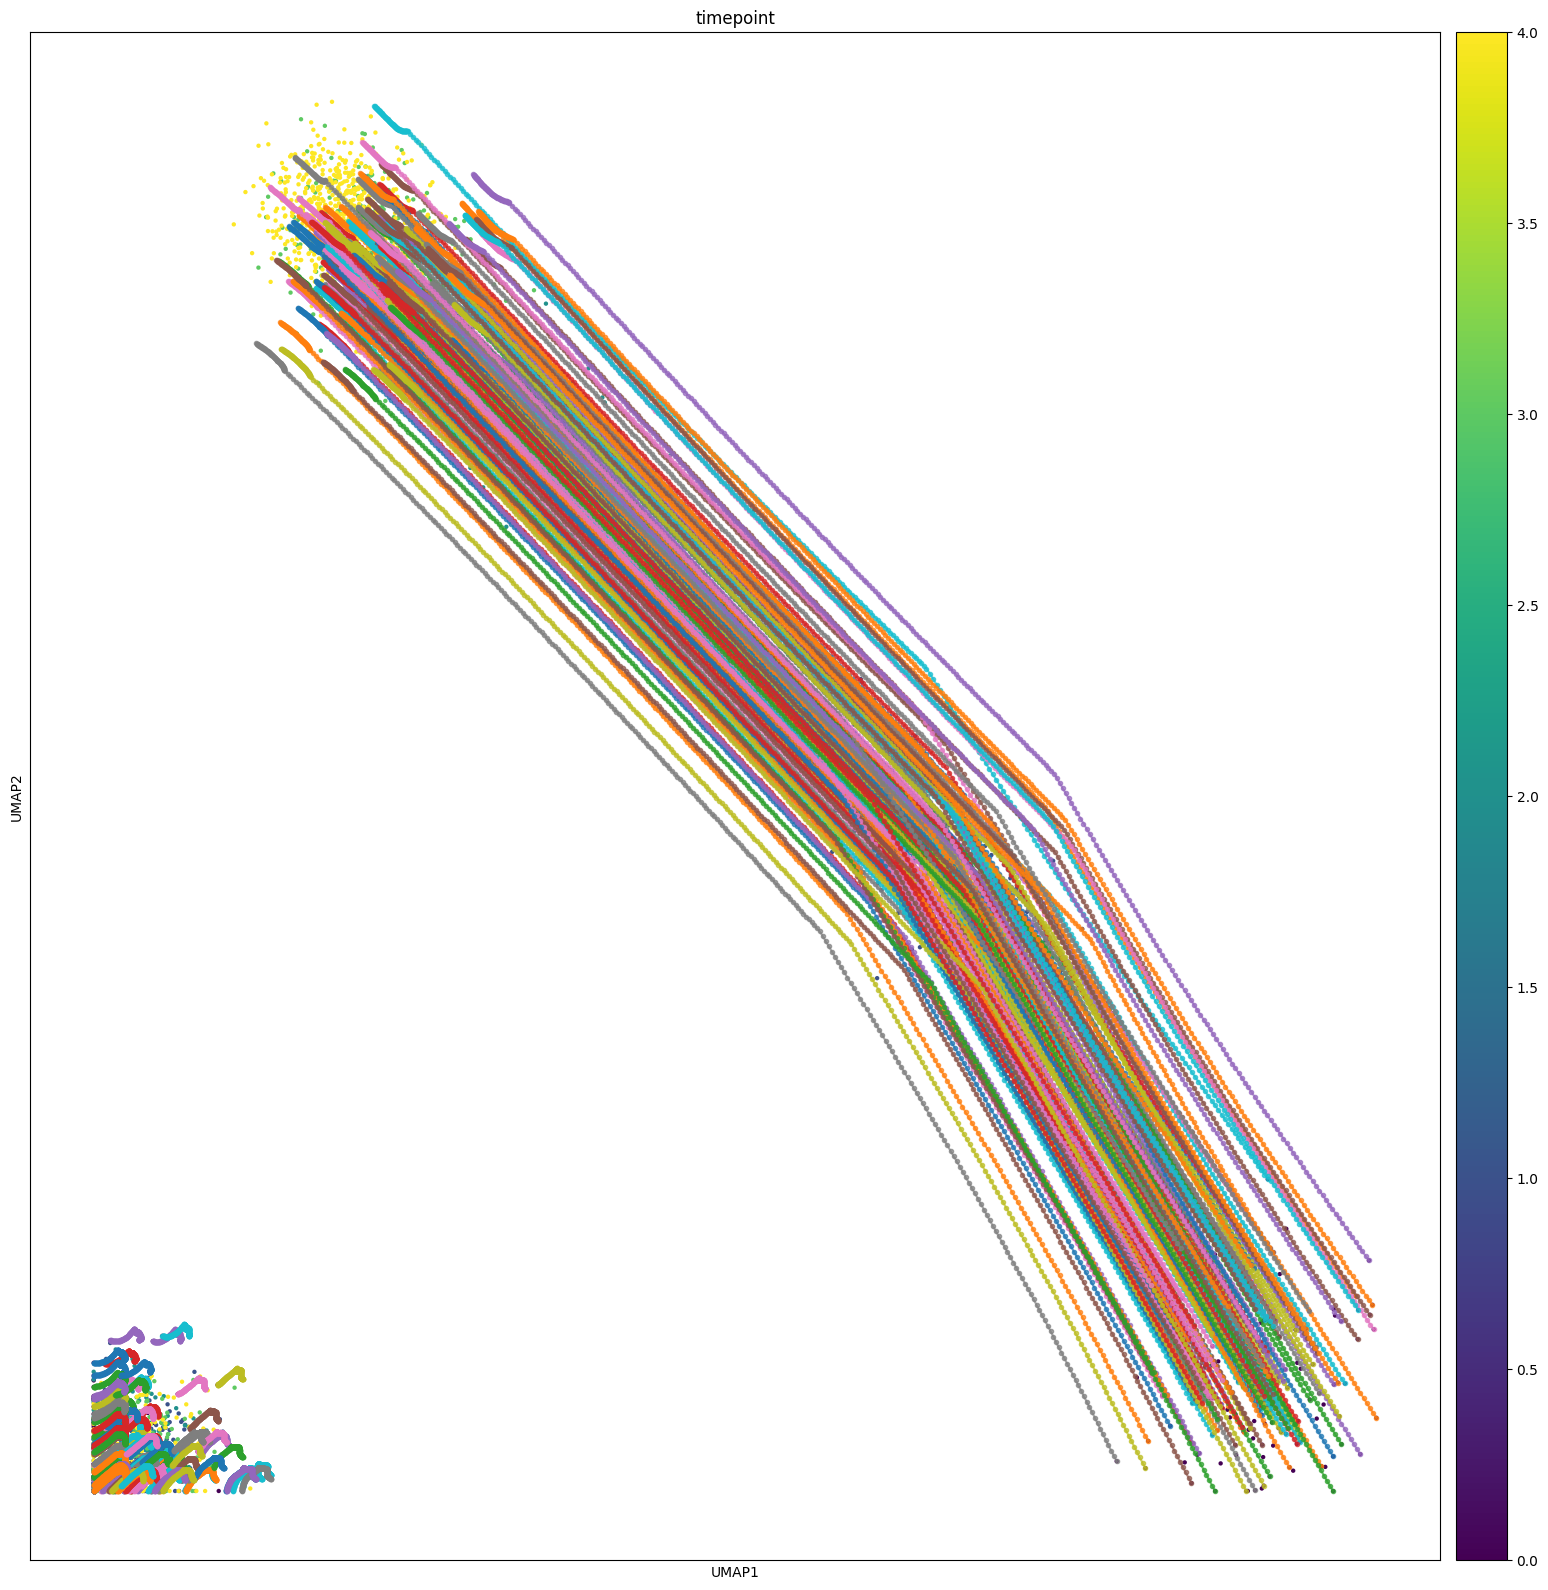

In [24]:
fig, ax = plt.subplots(figsize=(16, 16))
sc.pl.umap(adata, color="timepoint", ax=ax, show=False)

for i in range(num_traj):
    ax.plot(traj[:,i, 0], traj[:,i, 1], marker=".", linestyle="-", alpha=0.7, lw=1.5)

plt.tight_layout()
plt.show()

In [25]:
t0 = holdout_t - 1
t1 = holdout_t

X0 = adata[adata.obs['timepoint'] == t0].obsm['X_pca']
X1 = adata[adata.obs['timepoint'] == t1].obsm['X_pca']

num_traj = X0.shape[0]
    
c = conditions['ctrl-inj']
c = c.unsqueeze(0).repeat(num_traj, 1)


if config.model_class == "flow":
    samples = model.sample(X0, c, t0, t1, num_traj)
    samples = samples.detach().cpu().double()
    weights = None
else:
    samples, weights = model.sample_and_weight(X0, c, t0, t1, num_traj)
    samples = samples.detach().cpu().double()
    weights = weights.detach().cpu().double()

emp_dist = ot_dist(samples, torch.from_numpy(np.array(X1)), a = weights, b = None)

print(emp_dist)

0.19623127163390205


/home/azweig/projects/zebrafish/models/fm_models.py:204: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  ws = F.softmax(ws)


In [26]:
# def ot_dist_simpler(x, y, a = None, b = None):
#     x = x.cuda()
#     y = y.cuda()
#     loss = SamplesLoss(loss="sinkhorn", p=2, blur=.0005, debias=False, scaling=0.99)
#     if a is None:
#         a = torch.ones(x.shape[0]) / x.shape[0]
#     a = a.cuda()
#     if b is None:
#         b = torch.ones(y.shape[0]) / y.shape[0]
#     b = b.cuda()
#     return torch.sqrt(2 * loss(a, x, b, y)).item()

# emp_dist = ot_dist_simpler(samples, torch.from_numpy(np.array(X1)), a = weights, b = None)

# print(emp_dist)

In [27]:
import ot
def deepruot_ot_dist(x, y, a, b):
    x = x.cuda()
    y = y.cuda()
    if a is None:
        a = torch.ones(x.shape[0]) / x.shape[0]
    a = a.cuda()
    if b is None:
        b = torch.ones(y.shape[0]) / y.shape[0]
    b = b.cuda()

    # M = torch.cdist(x, y)**2
    M = ot.dist(x, y)

    return torch.sqrt(ot.emd2(a, b, M))

In [28]:
print(deepruot_ot_dist(samples, torch.from_numpy(np.array(X1)), a = weights, b = None))

tensor(0.2479, device='cuda:0', dtype=torch.float64)


In [29]:
stable_indices = np.where((samples[:, 0] <= 1) & (samples[:, 1] <= 1))[0]
growth_indices = np.where((samples[:, 0] > 1) | (samples[:, 1] > 1))[0]

stable_weight = torch.sum(weights[stable_indices])
growth_weight = torch.sum(weights[growth_indices])
print(stable_weight, growth_weight)

tensor(0.3702, dtype=torch.float64) tensor(0.6298, dtype=torch.float64)


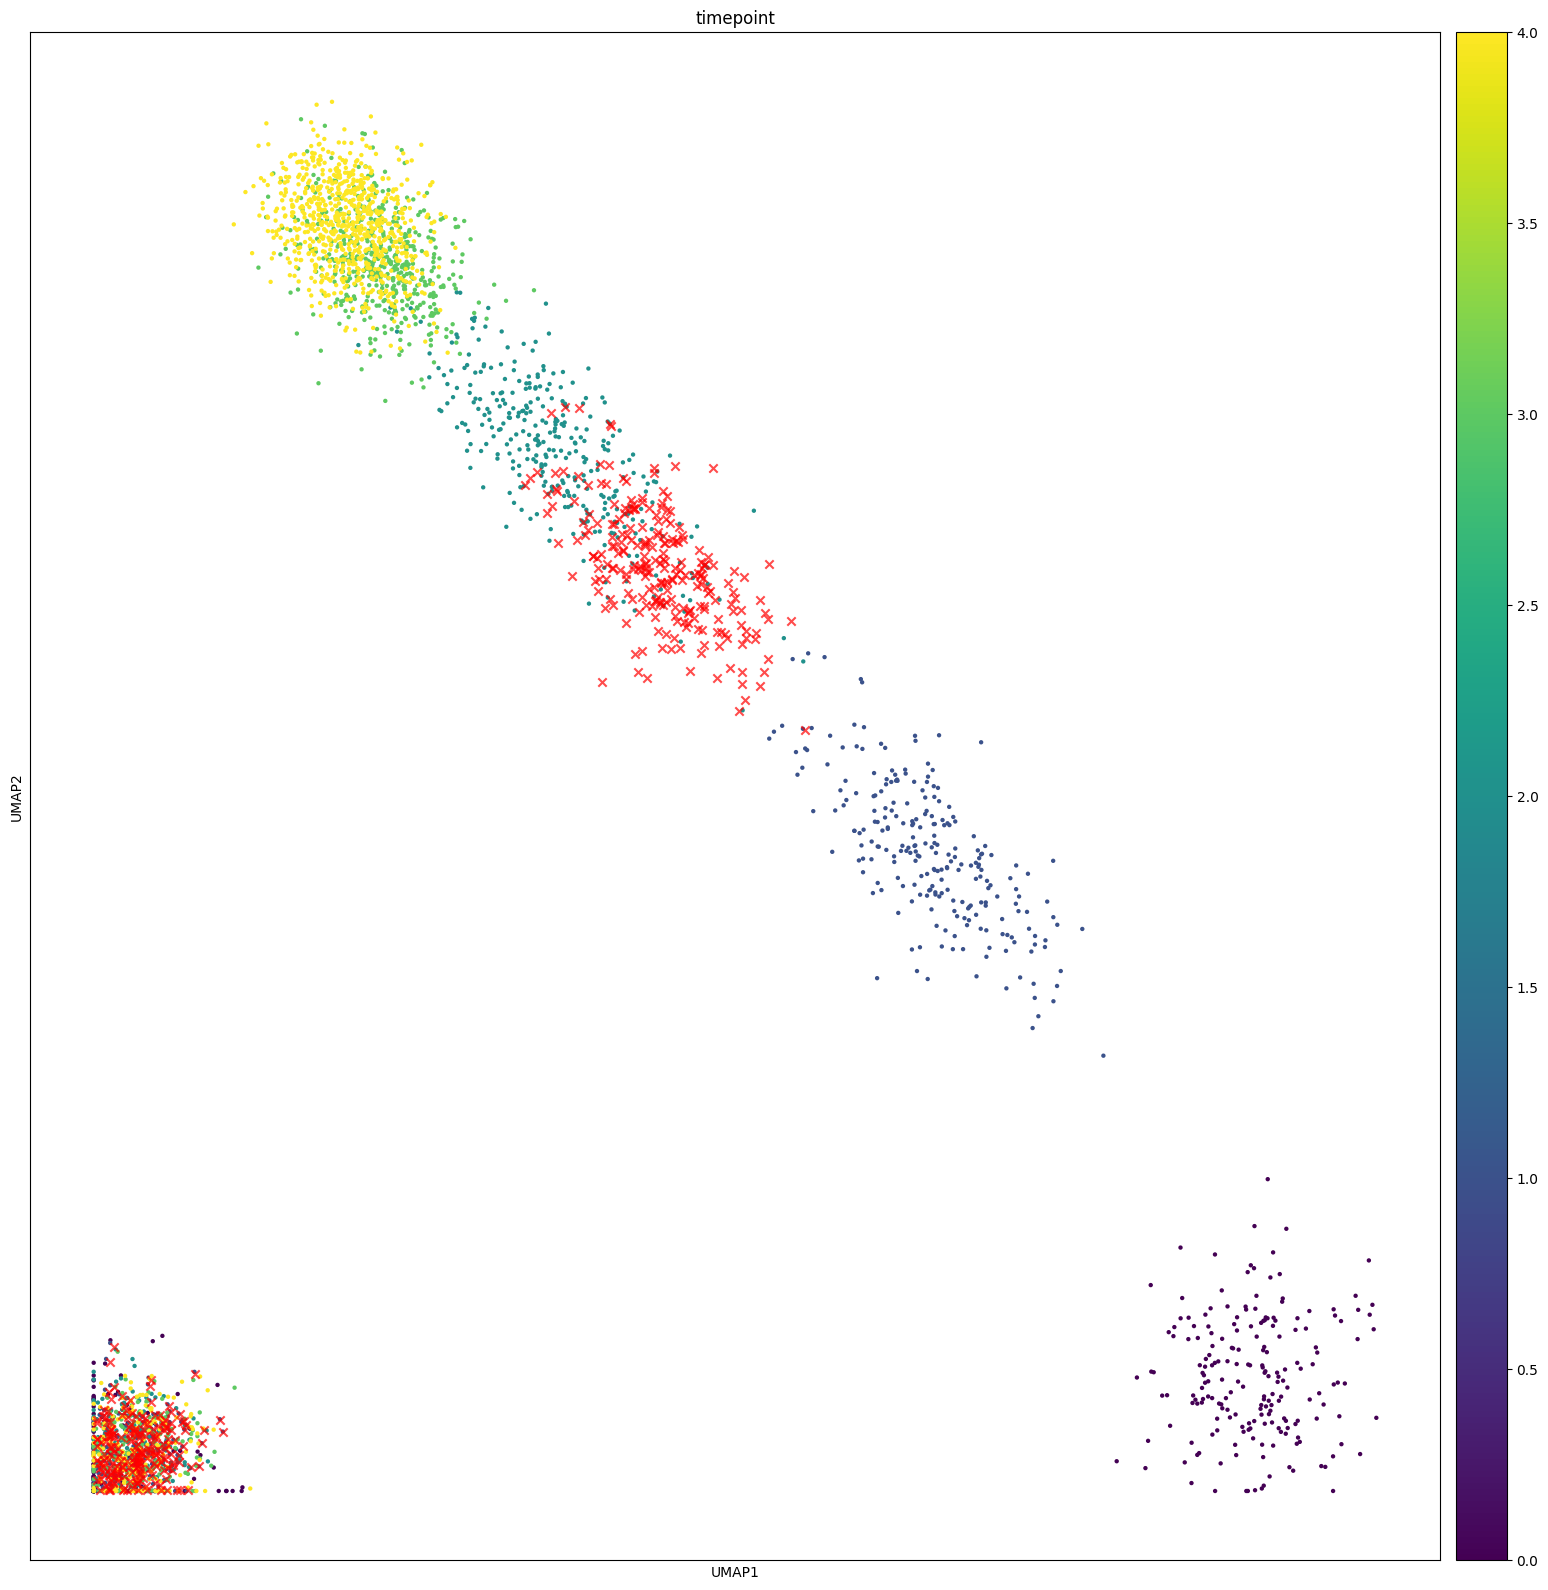

In [30]:
fig, ax = plt.subplots(figsize=(16, 16))
sc.pl.umap(adata, color="timepoint", ax=ax, show=False)

ax.scatter(samples[:,0], samples[:,1], marker="x", alpha=0.7, color="red")

plt.tight_layout()
plt.show()

In [31]:
'''
holdout:
t = 1, 0.1289
t = 2, 0.2649
t = 3, 0.1839
t = 4, 0.6076 (extrapolation) #TODO: try this with simple time parameterization, might generalize better
'''

'\nholdout:\nt = 1, 0.1289\nt = 2, 0.2649\nt = 3, 0.1839\nt = 4, 0.6076 (extrapolation)\n'